<a href="https://colab.research.google.com/github/scottspurlock/csc4466-s2026/blob/main/labs/day16_lab_spurlock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision Day 16 Lab: TensorFlow

In [30]:
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import numpy as np

## Download the data
- Separate into X, the images, and y, the target labels (0 - 9)
- Separate into training data and testing data

In [31]:
mnist = tf.keras.datasets.mnist

(Xtrain, ytrain), (Xtest, ytest) = mnist.load_data()

# normalize 0 - 1
Xtrain = Xtrain / 255.0
Xtest = Xtest / 255.0

In [32]:
print(Xtrain.shape)
print(Xtest.shape)

(60000, 28, 28)
(10000, 28, 28)


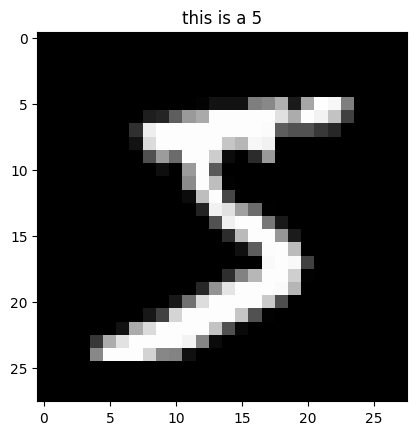

In [33]:
img = Xtrain[0]
label = ytrain[0]
plt.imshow(img, cmap='gray')
plt.title(f'this is a {label}');

## Define the model

In [34]:
# input must be 28x28 (size of input images)
# output must be 10 (number of different possible prediction labels)
# otherwise we can adjust number of hidden layers and number of neurons
model = tf.keras.models.Sequential([
    tf.keras.Input((28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(10)
])

## Predictions from an untrained model are just random
Note that we get 10 outputs because the last layer has 10 neurons

In [35]:
predictions = model(Xtrain[:1])
predictions

<tf.Tensor: shape=(1, 10), dtype=float32, numpy=
array([[-0.23264574, -0.1257231 ,  0.2750767 , -0.56997323,  0.11581942,
        -0.41852006, -0.03457214, -0.6145023 , -0.09714448,  0.110598  ]],
      dtype=float32)>

## Define the loss function

In [36]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

## Compile the model

In [37]:
model.compile(optimizer='sgd', loss=loss_fn, metrics=['accuracy'])

## Fit the model to the data
This is the training step where the model learns the weights (parameters)

In [38]:
model.fit(Xtrain, ytrain, epochs=8)

Epoch 1/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8691 - loss: 0.5219
Epoch 2/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9263 - loss: 0.2590
Epoch 3/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9415 - loss: 0.2084
Epoch 4/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9500 - loss: 0.1745
Epoch 5/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9578 - loss: 0.1501
Epoch 6/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9633 - loss: 0.1310
Epoch 7/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9676 - loss: 0.1157
Epoch 8/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9710 - loss: 0.1037


## Check how well the model generalizes
evaluate the model on the test data, which it hasn't seen before

In [39]:
results = model.evaluate(Xtest, ytest)

print(f'Test Loss: {results[0]}')
print(f'Test Accuracy: {results[1]}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9677 - loss: 0.1076
Test Loss: 0.10763394832611084
Test Accuracy: 0.9677000045776367


## Convert outputs to probabilities
Adding a softmax layer to the end makes the outputs sum to 1, so we can interpret them as probabilities

In [40]:
probability_model = tf.keras.Sequential([
    model,
    tf.keras.layers.Softmax()
])

The 10 outputs correspond to the 10 digits that are being predicted

In [41]:
probability_model.predict(Xtest[0:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step


array([[1.0127475e-04, 1.1547171e-06, 9.7797404e-04, 2.1191994e-03,
        1.0986364e-06, 2.7752169e-05, 8.3464258e-09, 9.9652749e-01,
        5.0068753e-05, 1.9392761e-04]], dtype=float32)

argmax gives the index of the max value

In [42]:
# get the index of the highest probability
prediction = np.argmax(probability_model.predict(Xtest[0:1]))
print(f'largest output is index {prediction}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
largest output is index 7


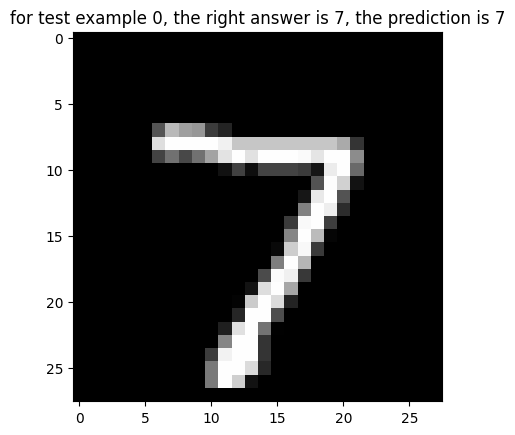

In [43]:
plt.imshow(Xtest[0], cmap='gray')
plt.title(f'for test example 0, the right answer is {ytest[0]}, the prediction is {prediction}')
plt.show()
